# Sulfuric Acid Calibration for CI-APi-TOF

**Author:** Cecilia Righi  
**Last update:** March 2026

**Description**: This notebook determines the calibration factor of a CI-APi-TOF instrument using sulfuric acid calibration experiment data together with modeled sulfuric acid concentrations.

**Workflow**:
1. Load previously preprocessed CI-APi-TOF data from the calibration experiment.  
2. Compute the normalized sulfuric acid signal (**SH2SO4**).  
3. Calculate the average SH2SO4 value for each calibration step.  
4. Load previously modeled H2SO4 concentrations (**[H2SO4]_modeled**).  
5. Determine the calibration factor as:  
   - **C_avg**: the average of the calibration factor calculated for each step  
   - **C_lin**: the slope of the linear regression `[H2SO4]_modeled = f(SH2SO4)`

In [ ]:
## 1 Load previously preprocessed CI-APi-TOF data from the calibration experiment
# Author: Lisa Beck

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os
import h5py
import warnings

# 1. Load previously preprocessed CI-APi-TOF data

# For interactive clicking in Jupyter, one of these may be needed:
# %matplotlib qt
# or
# %matplotlib notebook
# or, if those do not work in your setup, use:
# %matplotlib tk

def h5_read_file(filepath,UMR_num=-1):  
    
    '''

    Parameters
    ----------
    filepath : TYPE String
        Path to folder including all processed h5 files from Tofware. 
        Example: r"../../03_Data/CAFE_EU_02/CAFE_EU_02_2020-05-26/Avg-30/Processed/"
    UMR_num: number of UMR wanted

    Returns : dataframe including date and time as index, HR peaks and nominal unit mass as header and the corresponding data from the mass spec
    peak labels which can then be used for headers by converting the binary string to a string: 
        
    columns = ['unixtime', 'date']
    for i, label in enumerate(peaklabel):
        columns.append(label.decode())
    -------

    '''
    
    hf = h5py.File(filepath,'r')
    buftime = hf.get('TimingData/BufTimes') # buf time from h5 file
    buftime_h5file = buftime[()] # buftime readout in seconds from AcquisitionTimeZero

    DAQstart_h5file = hf['TimingData'].attrs['AcquisitionTimeZero'] # get start time of file 
    Tofperiod = hf['TimingData'].attrs['TofPeriod'] # Tofperiod used for converting from ions/extraction to ions/second

    time_h5file_matlab = ((DAQstart_h5file+(buftime_h5file*1e7))/(864000000000))+584755 # 584755 = (datenum(1601,1,1,0,0,0)), from IGOR converting to MATLAB
    time_h5file_unix = time_h5file_matlab-719529 # 719529 is the datenum of 01-01-1970 UNIX epoch 
    time_h5file_unix = np.reshape(time_h5file_unix,np.size(time_h5file_unix))
    df_time = pd.DataFrame(time_h5file_unix,columns = ['UnixTime']) # time to pandas dataframe, enables conversion to date
    
    for i in df_time:
        df_time['date'] = (pd.to_datetime(df_time[i],unit='d').round('s'))
   
    peaktable = hf['PeakData/PeakTable'][()]
    df_peaktable = pd.DataFrame(peaktable)

    peaklabel = df_peaktable['label']    
    exactmass = df_peaktable['mass']  
    peakname = []
    for i,label in enumerate(peaklabel):
        peakname.append(label.decode())
    
    
    peakdata = hf['PeakData/PeakData'][()]/Tofperiod*10**(9) # unit in ions/second
    peakdata = peakdata.reshape(-1,*peakdata.shape[-2:])
    # to judge whether UMR exists in the data file
    if('nominal2' in peakname):
        UMR_start=0
        #while cycle for confirming the starting position of UMR
        while peaklabel[UMR_start].decode()!='nominal2':
            UMR_start=UMR_start+1
        
        df_peakdata_HR = pd.DataFrame(peakdata[:,0,0:UMR_start],columns = peakname[0:UMR_start])
        if (UMR_num==-1):
            df_peakdata_UMR = pd.DataFrame(peakdata[:,0,UMR_start:],columns = df_peaktable['mass'][UMR_start:])
        else:
            # to judge whether the given number of UMR is our of range
            if (UMR_num>(np.size(df_peaktable['mass'])-UMR_start)):
                warnings.warn('The given number of UMR is out of the range')
                df_peakdata_UMR = pd.DataFrame(peakdata[:,0,UMR_start:],columns = df_peaktable['mass'][UMR_start:])
            else:
                df_peakdata_UMR = pd.DataFrame(peakdata[:,0,UMR_start:UMR_start+UMR_num],columns = df_peaktable['mass'][UMR_start:UMR_start+UMR_num])
        df = pd.concat([df_time, df_peakdata_HR, df_peakdata_UMR],axis=1) # df includes time, HR and part of UMR
    else:
        df_peakdata_HR = pd.DataFrame(peakdata[:,0,0:],columns = peakname[0:])
        df = pd.concat([df_time, df_peakdata_HR],axis=1)

    df.index = df['date'] 
    df=df.drop('UnixTime',axis=1)
    df=df.drop('date',axis=1)
    
    md = exactmass - round(exactmass)
    md_exactmass = pd.DataFrame([exactmass,md],index=['mass', 'massdefect'])
    md_exactmass.columns = peakname
    if ('Total ion current' in md_exactmass): 
        md_exactmass=md_exactmass.drop('Total ion current', axis=1)
    if ('nominal2' in md_exactmass): 
        md_exactmass = md_exactmass.drop('nominal2',axis=1)

    
    return df,md_exactmass

def h5_read_folder(filepath,UMR_num=-1):  
    '''

    Parameters
    ----------
    filepath : TYPE String
        Path to folder including all processed h5 files from Tofware. 
        Example: r"../../03_Data/CAFE_EU_02/CAFE_EU_02_2020-05-26/Avg-30/Processed/"
    UMR_num: number of UMR wanted

    Returns : dataframe including date and time as index, HR peaks and nominal unit mass as header and the corresponding data from the mass spec
    -------

    '''
    
    df_help = []
    for filename in os.listdir(filepath):
        if filename.endswith(".h5"): # make sure the file ends with .h5
            path = filepath+filename
            path=path.encode('unicode_escape').decode()
            
            [df,md_exactmass] = h5_read_file(path,UMR_num)
            df_help.append(df)
    df = pd.concat(df_help,axis=0)
    df=df.sort_index() # make sure that the data is in sequence regarding time
    
    return df,md_exactmass

# Set the actual file path where your .h5 files are located (use /)
folderpath = r"C:/LocalData/ceciliar/OneDrive - University of Helsinki/Documents/PhD/SMEAR_II/smearii_sa_calibration/example_presentation/Tofware/preaveraged/Processed/"

# Call the function to process all the .h5 files in that folder
df, md_exactmass = h5_read_folder(folderpath)

# Save the entire dataframe to a CSV file
df.to_csv(r"example_path\example_experiment.csv", index=True)

# Display the first few rows of the dataframe to verify it worked
df.head()

,NO3-,H2ONO3-,HSO4-,HNO3NO3-,HNO3HSO4-,(HNO3)2NO3-,H2SO4HSO4-,(H2SO4)2HSO4-
date,,,,,,,,
2026-01-22 08:38:10.870478378,7576.245480,1.090463,209.738275,1035.127298,29.435647,1.635786,3.487383,0.088144
2026-01-22 08:40:10.873699933,7484.094567,0.857257,194.376369,1017.224690,26.528726,1.013864,3.227155,0.109278
2026-01-22 08:42:10.876901374,7578.654731,0.968099,219.418254,1029.162831,30.410764,1.489222,3.448426,0.127994
2026-01-22 08:44:10.880143042,7627.326340,1.013286,231.909098,1045.266345,30.648039,1.594900,3.955443,0.085596
2026-01-22 08:46:10.883404833,7656.023627,1.162723,232.337385,1044.954388,32.011418,1.291353,3.717445,0.109350


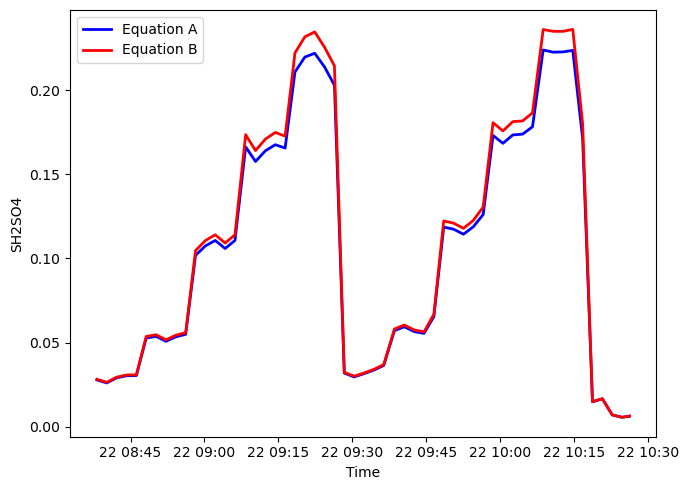

In [2]:
# 2. Compute the normalized sulfuric acid signal (SH2SO4)

# ---- Simplified equation (A) ----
num_A = df["HSO4-"] + df["HNO3HSO4-"]
den_A = df["NO3-"] + df["HNO3NO3-"] + df["H2ONO3-"]
df["SH2SO4_A"] = num_A / den_A
df.loc[den_A <= 0, "SH2SO4_A"] = np.nan

# ---- Complete equation (B) ----
num_B = df["HSO4-"] + df["HNO3HSO4-"] + df["H2SO4HSO4-"] + df["(H2SO4)2HSO4-"]
den_B = df["NO3-"] + df["HNO3NO3-"] + df["(HNO3)2NO3-"] + df["H2ONO3-"]
df["SH2SO4_B"] = num_B / den_B
df.loc[den_B <= 0, "SH2SO4_B"] = np.nan


import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import linregress
from scipy.io import loadmat

plt.figure(figsize=(7, 5))
plt.plot(df.index, df["SH2SO4_A"], linewidth=2, color='blue', label='Equation A')
plt.plot(df.index, df["SH2SO4_B"], linewidth=2, color='red', label='Equation B')
plt.ylabel('SH2SO4')
plt.xlabel('Time')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [3]:
# 3. Extract average SH2SO4 values for each calibration step
#
# The user manually selects time intervals corresponding to each calibration step.
# For each interval, the average SH2SO4 value is calculated and stored as:
# y_avg_cal_1, y_avg_cal_2, ...

%matplotlib qt
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(df.index, df["SH2SO4_B"], linewidth=2, color='red', label='Equation B')
ax.set_ylabel('SH2SO4')
ax.set_xlabel('Time')
ax.legend(loc='upper left')
ax.grid(True)
plt.tight_layout()
plt.show(block=False)

x = df.index.to_pydatetime()
y = df["SH2SO4_B"].to_numpy()

x_num = mdates.date2num(x)

cal_idx = 1
current_block = []
saved_calibrations = {}

while True:
    print("Click TWO points to define the averaging interval...")
    pts = plt.ginput(2, timeout=-1)

    if len(pts) < 2:
        print("Selection interrupted.")
        break

    x1 = min(pts[0][0], pts[1][0])
    x2 = max(pts[0][0], pts[1][0])

    idx = (x_num >= x1) & (x_num <= x2)

    if np.any(idx):
        y_avg = np.nanmean(y[idx])
    else:
        y_avg = np.nan
        print("Warning: No data points found in selected x-interval.")

    current_block.append(y_avg)
    print(f"Average for this interval: {y_avg:.10g}")

    action = input("0 = continue, 1 = save and stop, 2 = save and continue: ").strip()

    if action == "" or action == "0":
        continue

    elif action == "1":
        var_name = f"y_avg_cal_{cal_idx}"
        saved_calibrations[var_name] = np.array(current_block, dtype=float)
        globals()[var_name] = saved_calibrations[var_name]
        print(f"Saved {var_name} = {saved_calibrations[var_name]}")
        break

    elif action == "2":
        var_name = f"y_avg_cal_{cal_idx}"
        saved_calibrations[var_name] = np.array(current_block, dtype=float)
        globals()[var_name] = saved_calibrations[var_name]
        print(f"Saved {var_name} = {saved_calibrations[var_name]}")

        cal_idx += 1
        current_block = []

    else:
        print("Invalid input. Use 0, 1, or 2.")

Click TWO points to define the averaging interval...
Average for this interval: 0.0288443703
Click TWO points to define the averaging interval...
Average for this interval: 0.05357565729
Click TWO points to define the averaging interval...
Average for this interval: 0.1116230113
Click TWO points to define the averaging interval...
Average for this interval: 0.1749031413
Click TWO points to define the averaging interval...
Average for this interval: 0.23320493
Saved y_avg_cal_1 = [0.02884437 0.05357566 0.11162301 0.17490314 0.23320493]
Click TWO points to define the averaging interval...
Average for this interval: 0.0319882583
Click TWO points to define the averaging interval...
Average for this interval: 0.05897043742
Click TWO points to define the averaging interval...
Average for this interval: 0.1194456895
Click TWO points to define the averaging interval...
Average for this interval: 0.1796313184
Click TWO points to define the averaging interval...
Average for this interval: 0.2350

In [ ]:
# 4. Load previously modeled H2SO4 concentrations

model_path = r"example_path\model_file_name.mat"
model_data = loadmat(model_path)

H2Oconc = np.squeeze(model_data["H2Oconc"])
H2SO4   = np.squeeze(model_data["H2SO4"])

In [13]:
# 5a. Determine the calibration factor (single calibration)

import matplotlib.pyplot as plt
import numpy as np

H2Oconc_1 = np.ravel(H2Oconc)
H2SO4_1 = np.ravel(H2SO4)
y_avg_cal_1 = np.ravel(y_avg_cal_1)

if not (len(H2Oconc_1) == len(H2SO4_1) == len(y_avg_cal_1)):
    raise ValueError(
        f"Length mismatch: len(H2Oconc)={len(H2Oconc_1)}, "
        f"len(H2SO4)={len(H2SO4_1)}, len(y_avg_cal_1)={len(y_avg_cal_1)}"
    )


fig, ax1 = plt.subplots(figsize=(7, 5))
sc1 = ax1.scatter(H2Oconc_1, H2SO4_1,s=50, marker='o', linewidths=2,edgecolors='red', facecolors='none')
ax1.set_xlabel('[H2O] modeled, cm$^{-3}$')
ax1.set_ylabel('[H2SO4] modeled, cm$^{-3}$', color='k')
ax1.grid(True)
ax2 = ax1.twinx()
sc2 = ax2.scatter(H2Oconc_1, y_avg_cal_1,s=70, marker='x', linewidths=2,color='red')
ax2.set_ylabel('SH2SO4', color='k')
ax1.tick_params(axis='y', colors='k')
ax2.tick_params(axis='y', colors='k')
ax1.legend([sc1, sc2],['[H2SO4] modeled, cm$^{-3}$', 'SH2SO4'],loc='upper left')
plt.tight_layout()
plt.show()


# C_avg
C_avg = H2SO4_1 / y_avg_cal_1
mean_C_avg = np.nanmean(C_avg)
std_C_avg = np.nanstd(C_avg)
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(H2SO4_1, C_avg,linewidths=1.5,edgecolors='red',facecolors='none')
ax.set_xlabel('[H2SO4] modeled, cm$^{-3}$')
ax.set_ylabel('Calibration factor, cm$^{-3}$')
ax.set_ylim([0, np.nanmax(C_avg) + 3e9])
line_mean, = ax.plot([0, np.nanmax(H2SO4_1) + 0.5e8],[mean_C_avg, mean_C_avg],'k--',linewidth=1.5)
err = ax.errorbar(np.nanmax(H2SO4_1) + 0.5e8,mean_C_avg,yerr=std_C_avg,fmt='k.',linewidth=1.5)
ax.legend([sc, line_mean, err],['Calibration data', 'Mean calibration factor', 'Std calibration factor'],loc='lower left')
ax.text(np.nanmax(H2SO4_1) + 0.5e8,mean_C_avg,f' C = {mean_C_avg:.2e}',va='bottom',ha='right',fontsize=14,color='black')
ax.grid(True)
plt.tight_layout()
plt.show()


# C_lin
coeffs = np.polyfit(y_avg_cal_1, H2SO4_1, 1)
C_lin = coeffs[0]
fitline = np.polyval(coeffs, y_avg_cal_1)
sort_idx = np.argsort(y_avg_cal_1)
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(y_avg_cal_1, H2SO4_1, color='red')
ln, = ax.plot(y_avg_cal_1[sort_idx], fitline[sort_idx], 'k--', linewidth=1.5)
ax.set_xlabel('SH2SO4')
ax.set_ylabel('[H2SO4] modeled, cm$^{-3}$')
ax.legend([sc, ln],['Calibration data', f'Linear fit: C = {C_lin:.2e}'],loc='upper left')
ax.grid(True)
plt.tight_layout()
plt.show()

In [14]:
# 5b. Determine the calibration factor (two calibrations)

import matplotlib.pyplot as plt
import numpy as np

H2Oconc_1 = np.ravel(H2Oconc)
H2SO4_1 = np.ravel(H2SO4)
y_avg_cal_1 = np.ravel(y_avg_cal_1)
y_avg_cal_2 = np.ravel(y_avg_cal_2)

if not (len(H2Oconc_1) == len(H2SO4_1) == len(y_avg_cal_1) == len(y_avg_cal_2)):
    raise ValueError(
        f"Length mismatch: len(H2Oconc)={len(H2Oconc_1)}, "
        f"len(H2SO4)={len(H2SO4_1)}, len(y_avg_cal_1)={len(y_avg_cal_1)}, len(y_avg_cal_2)={len(y_avg_cal_2)}"
    )


fig, ax1 = plt.subplots(figsize=(7, 5))
sc1 = ax1.scatter(H2Oconc_1, H2SO4_1,s=50, marker='o', linewidths=2,edgecolors='red', facecolors='none')
ax1.set_xlabel('[H2O] modeled, cm$^{-3}$')
ax1.set_ylabel('[H2SO4] modeled, cm$^{-3}$', color='k')
ax1.grid(True)
ax2 = ax1.twinx()
sc2 = ax2.scatter(H2Oconc_1, y_avg_cal_1,s=70, marker='x', linewidths=2,color='red')
ax2.set_ylabel('SH2SO4', color='k')
ax1.tick_params(axis='y', colors='k')
ax2.tick_params(axis='y', colors='k')
ax1.legend([sc1, sc2],['[H2SO4] modeled, cm$^{-3}$', 'SH2SO4'],loc='upper left')
plt.tight_layout()
plt.show()

fig, ax1 = plt.subplots(figsize=(7, 5))
sc1 = ax1.scatter(H2Oconc_1, H2SO4_1,s=50, marker='o', linewidths=2,edgecolors='#FF8800', facecolors='none')
ax1.set_xlabel('[H2O] modeled, cm$^{-3}$')
ax1.set_ylabel('[H2SO4] modeled, cm$^{-3}$', color='k')
ax1.grid(True)
ax2 = ax1.twinx()
sc2 = ax2.scatter(H2Oconc_1, y_avg_cal_2,s=70, marker='x', linewidths=2,color='#FF8800')
ax2.set_ylabel('SH2SO4', color='k')
ax1.tick_params(axis='y', colors='k')
ax2.tick_params(axis='y', colors='k')
ax1.legend([sc1, sc2],['[H2SO4] modeled, cm$^{-3}$', 'SH2SO4'],loc='upper left')
plt.tight_layout()
plt.show()


# C_avg
C_avg_1 = H2SO4_1 / y_avg_cal_1
C_avg_2 = H2SO4_1 / y_avg_cal_2
C_avg = np.concatenate([C_avg_1,C_avg_2])
mean_C_avg = np.nanmean(C_avg)
std_C_avg = np.nanstd(C_avg)
fig, ax = plt.subplots(figsize=(7, 5))
sc1 = ax.scatter(H2SO4_1, C_avg_1,linewidths=1.5,edgecolors='red',facecolors='none')
sc2 = ax.scatter(H2SO4_1, C_avg_2,linewidths=1.5,edgecolors='#FF8800',facecolors='none')
ax.set_xlabel('[H2SO4] modeled, cm$^{-3}$')
ax.set_ylabel('Calibration factor, cm$^{-3}$')
ax.set_ylim([0, np.nanmax(C_avg) + 3e9])
line_mean, = ax.plot([0, np.nanmax(H2SO4_1) + 0.5e8],[mean_C_avg, mean_C_avg],'k--',linewidth=1.5)
err = ax.errorbar(np.nanmax(H2SO4_1) + 0.5e8,mean_C_avg,yerr=std_C_avg,fmt='k.',linewidth=1.5)
ax.legend([sc1, sc2, line_mean, err],['Calibration 1 data','Calibration 2 data','Mean calibration factor','Std calibration factor'],loc='lower left')
ax.text(np.nanmax(H2SO4_1) + 0.5e8,mean_C_avg,f' C = {mean_C_avg:.2e}',va='bottom',ha='right',fontsize=14,color='black')
ax.grid(True)
plt.tight_layout()
plt.show()


# C_lin
coeffs1 = np.polyfit(y_avg_cal_1, H2SO4_1, 1)
C_lin_1 = coeffs1[0]
fit1 = np.polyval(coeffs1, y_avg_cal_1)
coeffs2 = np.polyfit(y_avg_cal_2, H2SO4_1, 1)
C_lin_2 = coeffs2[0]
fit2 = np.polyval(coeffs2, y_avg_cal_2)
mean_C_lin = np.mean([C_lin_1,C_lin_2])
sort_idx1 = np.argsort(y_avg_cal_1)
sort_idx2 = np.argsort(y_avg_cal_2)
fig, ax = plt.subplots(figsize=(7, 5))
sc1 = ax.scatter(y_avg_cal_1, H2SO4_1, color='red')
ln1, = ax.plot(y_avg_cal_1[sort_idx1], fit1[sort_idx1], 'r--', linewidth=1.5)
sc2 = ax.scatter(y_avg_cal_2, H2SO4_1, color='#FF8800')
ln2, = ax.plot(y_avg_cal_2[sort_idx2], fit2[sort_idx2], 'y--', linewidth=1.5)
dummy, = ax.plot([], [], 'k:')
ax.set_xlabel('SH2SO4')
ax.set_ylabel('[H2SO4] modeled, cm$^{-3}$')
ax.legend([sc1, ln1, sc2, ln2, dummy],['Calibration 1 data', f'C1 = {C_lin_1:.2e}','Calibration 2 data', f'C2 = {C_lin_2:.2e}', f'C = {mean_C_lin:.2e}'],loc='upper left')
ax.grid(True)
plt.tight_layout()
plt.show()